### Supplementary Figures S1 & S2, and Supplementary Tables S1 & 2

* Supplementary figure & table S1 correspond to association of essentiality with hubs
* Supplementary figure & table S2 correspond to association of phosphorylation with hubs 

In [34]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm, trange
import numpy as np
import networkx as nx
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from typing import Dict, Optional

In [35]:
def bootstrap_ct_fast(
    df: pd.DataFrame,
    col1: str,
    col2: str,
    n: Optional[int] = None,
    B: int = 1_000_000,
    alpha: float = 0.05,
    seed: Optional[int] = 0,
    correction: float = 0.0,   
) -> Dict[str, object]:
    
    sub = df[[col1, col2]].dropna().astype(bool)
    N = len(sub)
    if N == 0:
        raise ValueError("No rows after dropping NA.")
    if n is None:
        n = N

    # observed counts
    a = int(((sub[col1]) & (sub[col2])).sum())              # True, True
    b = int(((sub[col1]) & (~sub[col2])).sum())             # True, False
    c = int(((~sub[col1]) & (sub[col2])).sum())             # False, True
    d = int(((~sub[col1]) & (~sub[col2])).sum())            # False, False

    table = np.array([[a, b],
                      [c, d]], dtype=int)

    # "Observed" odds ratio from Fisher's exact test (fine to do once)
    odds_ratio_fisher, p_value = fisher_exact(table, alternative="two-sided")

    # Also compute the standard cross-product OR (used for bootstrap below)
    or_obs = ((a + correction) * (d + correction)) / ((b + correction) * (c + correction))
    odds1_obs = (a + correction) / (b + correction)
    odds2_obs = (c + correction) / (d + correction)

    # Multinomial probabilities from empirical distribution
    p = np.array([a, b, c, d], dtype=float) / N

    rng = np.random.default_rng(seed)

    # Draw all bootstrap tables at once (very fast)
    boot = rng.multinomial(n, p, size=B).astype(np.int32)
    boot_a, boot_b, boot_c, boot_d = boot.T  # each is (B,)

    # Vectorized odds / OR with correction
    boot_odds1 = (boot_a + correction) / (boot_b + correction)
    boot_odds2 = (boot_c + correction) / (boot_d + correction)
    boot_or    = ((boot_a + correction) * (boot_d + correction)) / ((boot_b + correction) * (boot_c + correction))

    # percentile CIs
    lo_q = alpha / 2
    hi_q = 1 - alpha / 2

    def ci(x: np.ndarray):
        return (float(np.quantile(x, lo_q)), float(np.quantile(x, hi_q)))

    a_ci = ci(boot_a); b_ci = ci(boot_b); c_ci = ci(boot_c); d_ci = ci(boot_d)
    odds1_ci = ci(boot_odds1); odds2_ci = ci(boot_odds2); or_ci = ci(boot_or)

    return {
        "a": a, "b": b, "c": c, "d": d,
        "a_lower": a_ci[0], "a_upper": a_ci[1],
        "b_lower": b_ci[0], "b_upper": b_ci[1],
        "c_lower": c_ci[0], "c_upper": c_ci[1],
        "d_lower": d_ci[0], "d_upper": d_ci[1],

        # Fisher OR / p-value for the observed table 
        "odds_ratio_fisher": float(odds_ratio_fisher),
        "p_value_fisher": float(p_value),

        # bootstrap distribution information for the cross-product OR and per-row odds
        "odds_ratio": float(or_obs), "odds_ratio_lower": or_ci[0], "odds_ratio_upper": or_ci[1],
        "row1_odds": float(odds1_obs), "row1_odds_lower": odds1_ci[0], "row1_odds_upper": odds1_ci[1],
        "row2_odds": float(odds2_obs), "row2_odds_lower": odds2_ci[0], "row2_odds_upper": odds2_ci[1],

    }

In [36]:
NODES = "../../flatten/processed-data/20251209-s288c-annotated-PPI-net.pkl"
nodes = pd.read_pickle(NODES)

# determine which nodes are hubs based on quantile cutoff for degree centrality
cut          = 0.10
threshold    = nodes["degree_centrality"].quantile(1 - cut)
nodes["hub"] = nodes["degree_centrality"] >= threshold

# use a joint criteria to define proteins as phosphorylated or not phosphorylated
has_phospho_flag = (nodes["ptm_gold"].notna())
has_phospho_text = nodes["parsed_PTMs"].str.contains(
    "phospho", case=False, na=False
)
nodes["phosphorylated"] = has_phospho_flag | has_phospho_text

In [37]:
results1 = bootstrap_ct_fast(nodes, "hub", "essential", 3927, B=1_000_000, alpha=0.05)
results2 = bootstrap_ct_fast(nodes, "hub", "phosphorylated", 3927, B=1_000_000, alpha=0.05)

In [41]:
results1

{'a': 166,
 'b': 227,
 'c': 856,
 'd': 2678,
 'a_lower': 142.0,
 'a_upper': 191.0,
 'b_lower': 199.0,
 'b_upper': 256.0,
 'c_lower': 806.0,
 'c_upper': 907.0,
 'd_lower': 2621.0,
 'd_upper': 2735.0,
 'odds_ratio_fisher': 2.287805179299271,
 'p_value_fisher': 1.7844734243439008e-13,
 'odds_ratio': 2.287805179299271,
 'odds_ratio_lower': 1.841714245904966,
 'odds_ratio_upper': 2.8333538572617396,
 'row1_odds': 0.7312775330396476,
 'row1_odds_lower': 0.5967741935483871,
 'row1_odds_upper': 0.8920454545454546,
 'row2_odds': 0.3196415235250187,
 'row2_odds_lower': 0.2955791012056997,
 'row2_odds_upper': 0.34490652422739415}

In [42]:
results2

{'a': 312,
 'b': 81,
 'c': 2470,
 'd': 1064,
 'a_lower': 279.0,
 'a_upper': 346.0,
 'b_lower': 64.0,
 'b_upper': 99.0,
 'c_lower': 2411.0,
 'c_upper': 2529.0,
 'd_lower': 1010.0,
 'd_upper': 1119.0,
 'odds_ratio_fisher': 1.6592592592592592,
 'p_value_fisher': 6.60099196762324e-05,
 'odds_ratio': 1.6592592592592592,
 'odds_ratio_lower': 1.2989812901621802,
 'odds_ratio_upper': 2.172038881876959,
 'row1_odds': 3.8518518518518516,
 'row1_odds_lower': 3.0510204081632653,
 'row1_odds_upper': 5.0,
 'row2_odds': 2.3214285714285716,
 'row2_odds_lower': 2.162016201620162,
 'row2_odds_upper': 2.496538081107814}

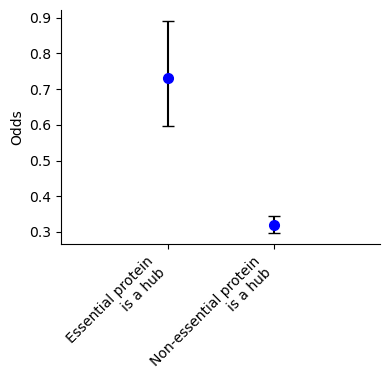

In [38]:
labels = ["Essential protein\nis a hub", "Non-essential protein\nis a hub"]
y = np.array([results1["row1_odds"], results1["row2_odds"]])
ci_lo = np.array([results1["row1_odds_lower"], results1["row2_odds_lower"]])
ci_hi = np.array([results1["row1_odds_upper"], results1["row2_odds_upper"]])

x = np.array([2, 3])

yerr = np.vstack([y - ci_lo, ci_hi - y])

fig, ax = plt.subplots(figsize=(4, 4))  # square 3x3 inches

ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    capsize=4,
    elinewidth=1.5,
    markersize=7,
    color="blue",     # marker + line color base
    ecolor="black",   # error bar color
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Odds")
ax.set_xlim(1, 4)

plt.tight_layout()
plt.savefig("s1.pdf", dpi=300)

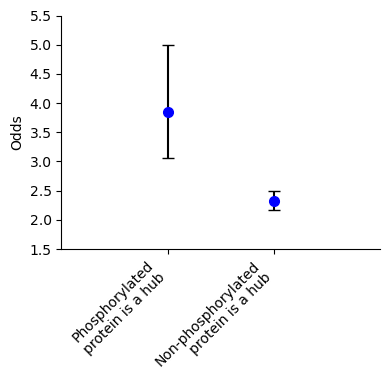

In [39]:
labels = ["Phosphorylated\nprotein is a hub", "Non-phosphorylated\nprotein is a hub"]
y = np.array([results2["row1_odds"], results2["row2_odds"]])
ci_lo = np.array([results2["row1_odds_lower"], results2["row2_odds_lower"]])
ci_hi = np.array([results2["row1_odds_upper"], results2["row2_odds_upper"]])

x = np.array([2, 3])

yerr = np.vstack([y - ci_lo, ci_hi - y])

fig, ax = plt.subplots(figsize=(4, 4))  # square 3x3 inches

ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    capsize=4,
    elinewidth=1.5,
    markersize=7,
    color="blue",     
    ecolor="black",   
)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylim(1.5, 5.5)
ax.set_ylabel("Odds")
ax.set_xlim(1, 4)

plt.tight_layout()
plt.savefig("s2.pdf", dpi=300)

In [40]:
list(nodes.columns)

['node',
 '_wkshell',
 'degree_centrality',
 'betweenness_centrality',
 'eigenvector_centrality',
 'closeness_centrality',
 'load_centrality',
 'pagerank',
 'information_centrality',
 'CentralityCosDist_rank',
 'CentralityCosDist_similarity_score',
 'has_verified_sequence',
 'sequence',
 'UniProtKB-AC',
 'DeepTMHMM_trimmed_sequence',
 'DeepTMHMM_class',
 'cleavage_site_start',
 'signalP_trimmed_sequence',
 'ProteinName',
 'GO_terms',
 'GO_terms_human_readable',
 'localization_keywords',
 'parsed_functions',
 'parsed_PTMs',
 'ptm_bronze',
 'ptm_gold',
 'ptm_silver',
 'IDR_count',
 'IDR_sequences',
 'IDR_ranges',
 'N_aa_disordered',
 'disorder_fraction',
 'is_disordered_0.05',
 'is_disordered_0.10',
 'is_disordered_0.15',
 'is_disordered_0.20',
 'is_disordered_0.25',
 'is_disordered_0.30',
 'is_disordered_0.35',
 'is_disordered_0.40',
 'is_disordered_0.45',
 'is_disordered_0.50',
 'is_disordered_0.55',
 'is_disordered_0.60',
 'is_disordered_0.65',
 'is_disordered_0.70',
 'is_disordered_0